# Inflation Base Effects: Signal, Backtest, and Evaluation

## Objective

Evaluate whether a pre-specified inflation base-effect signal produces positive
returns in a duration-neutral portfolio of four sovereign 10-year bond proxies.

The research design is falsification-oriented: the signal direction is not
reversed after observing the result, and robustness variants are reported as
diagnostics rather than replacements for the primary specification.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter

from inflation_base_effects.data import REPO_ROOT, compute_base_effect, load_cpi, load_yields
from inflation_base_effects.evaluation import (
    EmpPerfStats,
    hac_mean_inference,
    portfolio_returns,
    regime_stability,
    rolling_hac_mean,
)
from inflation_base_effects.portfolio import (
    compute_bond_returns,
    ewmacov,
    full_backtest,
    rank_dv01_holdings,
)
from inflation_base_effects.signals import (
    calc_month_of_year_signal,
    calc_signal_from_base_effect,
)

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")


## Pre-specified signal and timing

The primary signal is the NSA log-CPI print rolling out of the YoY window. It is
scored with a six-month EWM z-score, capped at ±2, and delayed one month. A
holding formed at month `t` earns the complete-case return at `t+1`; the first
date without prior holdings is excluded rather than recorded as zero.


In [2]:
headline_nsa = load_cpi()
yields_monthly = load_yields()
bond_returns, bond_duration = compute_bond_returns(yields_monthly)
rolling_off = compute_base_effect(headline_nsa)
last_return_date = bond_returns.dropna(how="all").index[-1]

primary_score = calc_signal_from_base_effect(
    rolling_off, last_return_date, hl=6, implag=1
).dropna(how="any")
month_score = calc_month_of_year_signal(
    rolling_off, last_return_date, min_history=5, implag=1
).dropna(how="any")

covariance = ewmacov(
    bond_returns.dropna(), halflife=(12, 36), shrinkage_factor=0.3
)
primary_h, _, primary_perf, diagnostics = full_backtest(
    primary_score, covariance, bond_returns, bond_duration
)
month_h, _, month_perf, _ = full_backtest(
    month_score, covariance, bond_returns, bond_duration
)
rank_h = rank_dv01_holdings(primary_score, bond_duration, gross_exposure=1.0)
rank_perf = EmpPerfStats(rank_h, bond_returns)


## Primary result and core robustness

- **Primary:** original NSA/EWM signal in the constrained optimizer.
- **Month-of-year:** strictly expanding same-calendar-month normalization,
  using only prior observations and a five-observation warm-up.
- **Rank/DV01:** optimizer-free top-two versus bottom-two implementation with
  unit gross exposure and exact DV01 neutrality.


In [3]:
def performance_row(label, performance):
    returns = performance.port_ret
    inference = hac_mean_inference(returns)
    return {
        "specification": label,
        "start": returns.index.min().strftime("%Y-%m"),
        "end": returns.index.max().strftime("%Y-%m"),
        "N": len(returns),
        "ann_return": performance.ann_ret,
        "ann_vol": performance.ann_vol,
        "return_to_vol": performance.IR,
        "NW t-stat": inference["NW t-stat"],
        "NW p-value": inference["NW p-value"],
        "max_drawdown": performance.max_dd,
    }


performance_table = pd.DataFrame(
    [
        performance_row("Primary NSA/EWM optimizer", primary_perf),
        performance_row("Expanding month-of-year optimizer", month_perf),
        performance_row("Primary signal rank/DV01", rank_perf),
    ]
).set_index("specification")
display(performance_table)


,start,end,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,max_drawdown
specification,,,,,,,,,
Primary NSA/EWM optimizer,1991-09,2024-12,400,-0.0008,0.0275,-0.0289,-0.1845,0.8536,-0.1726
Expanding month-of-year optimizer,1996-04,2024-12,345,0.0054,0.0284,0.1911,1.1788,0.2385,-0.1013
Primary signal rank/DV01,1991-09,2024-12,400,-0.0002,0.0142,-0.0148,-0.0902,0.9282,-0.1067


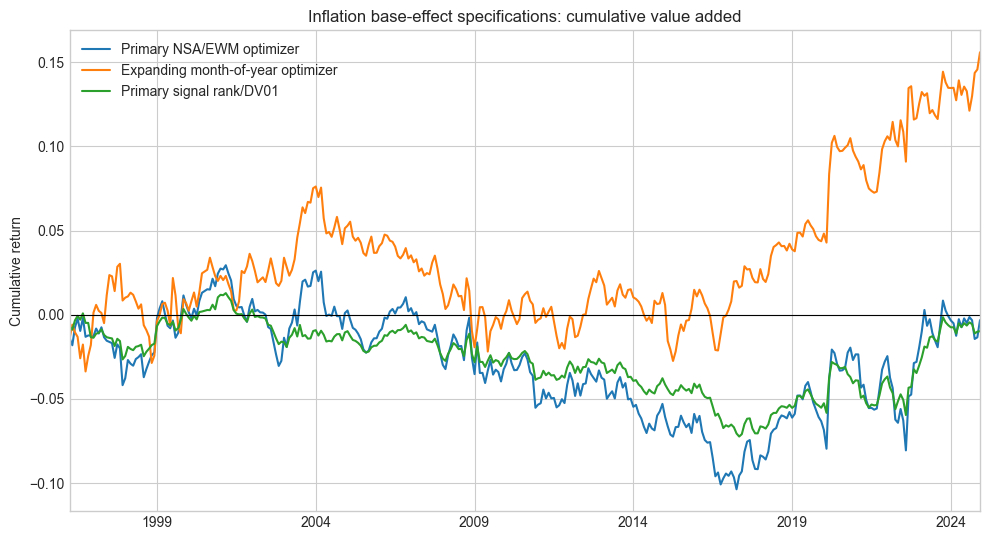

In [4]:
comparison_returns = pd.concat(
    {
        "Primary NSA/EWM optimizer": primary_perf.port_ret,
        "Expanding month-of-year optimizer": month_perf.port_ret,
        "Primary signal rank/DV01": rank_perf.port_ret,
    },
    axis=1,
    join="inner",
)
comparison_va = comparison_returns.cumsum()

fig, ax = plt.subplots(figsize=(10, 5.5))
comparison_va.plot(ax=ax, linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Inflation base-effect specifications: cumulative value added")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("")
ax.legend(frameon=False)
fig.tight_layout()

figure_path = Path(REPO_ROOT) / "docs" / "figures" / "strategy_summary.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()


## Portfolio diagnostics


In [5]:
diag = diagnostics.copy()
diag["ex_ante_vol"] = np.sqrt(12 * diag["ex_ante_var"])
constraint_summary = pd.Series(
    {
        "months optimized": len(diag),
        "non-optimal solver statuses": (~diag["solver_status"].isin(["optimal", "optimal_inaccurate"])).sum(),
        "max absolute duration residual": diag["duration_residual"].abs().max(),
        "max gross exposure": diag["gross_exposure"].max(),
        "max absolute position": diag["max_position"].max(),
        "max annualized ex-ante volatility": diag["ex_ante_vol"].max(),
        "position cap binding pct": 100 * (primary_h.abs() >= 0.5 - 1e-3).any(axis=1).mean(),
    },
    name="value",
)
display(constraint_summary.to_frame())

assert diag["duration_residual"].abs().max() < 1e-3
assert diag["gross_exposure"].max() <= 2.0 + 1e-3
assert diag["max_position"].max() <= 0.5 + 1e-3
assert diag["ex_ante_vol"].max() <= 0.10 + 1e-3


,value
months optimized,401.0000
non-optimal solver statuses,0.0000
max absolute duration residual,0.0000
max gross exposure,2.0000
max absolute position,0.5000
max annualized ex-ante volatility,0.0554
position cap binding pct,99.7506


## Transaction costs


In [6]:
turnover = primary_h.diff().fillna(primary_h).abs().sum(axis=1)
cost_turnover = turnover.shift(1).reindex(primary_perf.port_ret.index)
cost_rows = []
for bps in [1, 3, 5, 10]:
    net = primary_perf.port_ret - cost_turnover * bps / 10_000
    cost_rows.append(
        {
            "one-way cost bp": bps,
            "ann_return": 12 * net.mean(),
            "ann_vol": np.sqrt(12) * net.std(),
            "return_to_vol": np.sqrt(12) * net.mean() / net.std(),
        }
    )
display(pd.DataFrame(cost_rows).set_index("one-way cost bp"))


,ann_return,ann_vol,return_to_vol
one-way cost bp,,,
1,-0.0032,0.0275,-0.1154
3,-0.0079,0.0275,-0.2882
5,-0.0127,0.0275,-0.4605
10,-0.0246,0.0277,-0.8859


## Signal decay and temporal stability

The stability test retains the notebook's pre-existing 2010 split rather than
searching for a favorable breakpoint. The post-minus-pre coefficient tests
whether average performance changed, with Newey–West inference. The split is
not interpreted as a causal publication or market-adoption date.

The test is applied to the primary signal through both the constrained
optimizer and optimizer-free rank/DV01 implementation. The post-hoc
month-of-year variant is deliberately excluded.


In [7]:
STABILITY_SPLIT = pd.Timestamp("2010-01-01")
optimizer_stability = regime_stability(primary_perf.port_ret, STABILITY_SPLIT)
rank_stability = regime_stability(rank_perf.port_ret, STABILITY_SPLIT)

stability_table = pd.concat(
    {
        "Primary NSA/EWM optimizer": optimizer_stability,
        "Primary signal rank/DV01": rank_stability,
    },
    names=["implementation", "period"],
)
display(stability_table)


N  ann_return  ann_vol  \
implementation            period                                         
Primary NSA/EWM optimizer pre            220.0000     -0.0030   0.0280   
                          post           180.0000      0.0020   0.0269   
                          post_minus_pre 400.0000      0.0050      NaN   
Primary signal rank/DV01  pre            220.0000     -0.0013   0.0145   
                          post           180.0000      0.0011   0.0138   
                          post_minus_pre 400.0000      0.0025      NaN   

                                          return_to_vol  NW t-stat  \
implementation            period                                     
Primary NSA/EWM optimizer pre                   -0.1088    -0.5180   
                          post                   0.0725     0.2866   
                          post_minus_pre            NaN     0.5762   
Primary signal rank/DV01  pre                   -0.0910    -0.4256   
                          post                   0.0829     0.3130   
                          post_minus_pre            NaN     0.5239   

                                          NW p-value  CI 95% lower  \
implementation            period                                     
Primary NSA/EWM optimizer pre                 0.6045       -0.0146   
                          post                0.7744       -0.0114   
                          post_minus_pre      0.5645       -0.0120   
Primary signal rank/DV01  pre                 0.6704       -0.0074   
                          post                0.7542       -0.0060   
                          post_minus_pre      0.6003       -0.0067   

                                          CI 95% upper  NW maxlags  
implementation            period                                    
Primary NSA/EWM optimizer pre                   0.0085      4.0000  
                          post                  0.0153      4.0000  
                          post_minus_pre        0.0220      5.0000  
Primary signal rank/DV01  pre                   0.0047      4.0000  
                          post                  0.0083      4.0000  
                          post_minus_pre        0.0117      5.0000

The rolling estimates below use trailing 120-month windows only. Their
overlap makes them descriptive; they visualize instability but do not provide
independent tests or identify when market participants learned the signal.


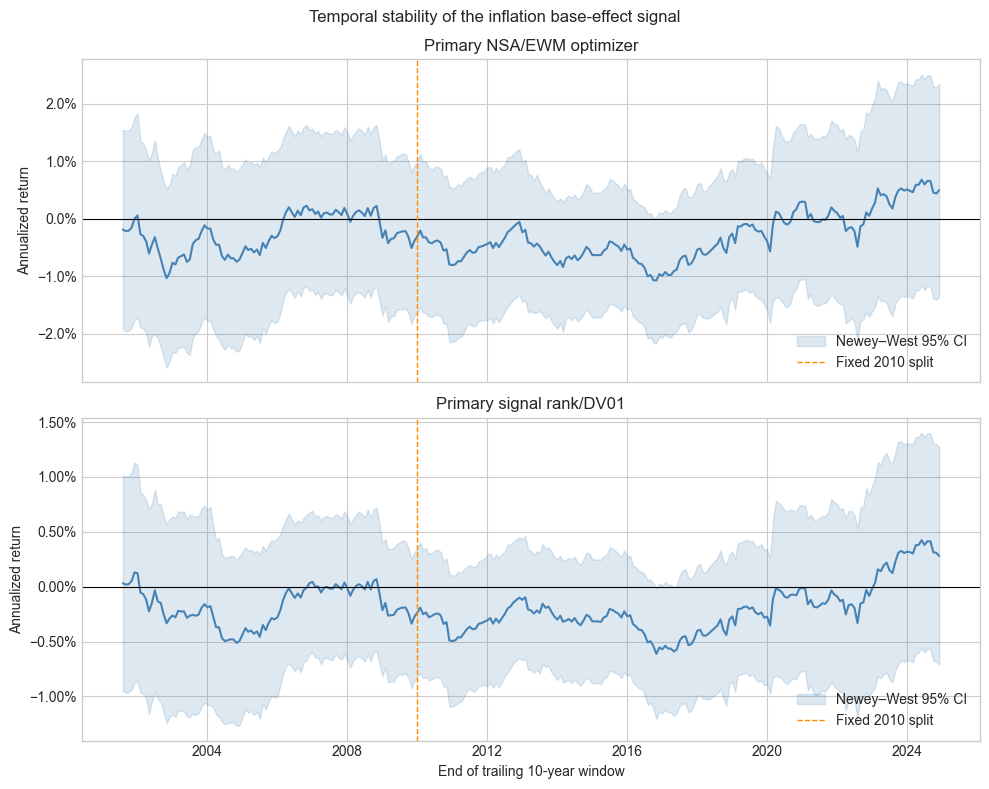

In [8]:
rolling_primary = rolling_hac_mean(primary_perf.port_ret, window=120)
rolling_rank = rolling_hac_mean(rank_perf.port_ret, window=120)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for ax, (label, rolling) in zip(
    axes,
    [
        ("Primary NSA/EWM optimizer", rolling_primary),
        ("Primary signal rank/DV01", rolling_rank),
    ],
    strict=True,
):
    ax.plot(rolling.index, rolling["ann_return"], color="steelblue", linewidth=1.5)
    ax.fill_between(
        rolling.index,
        rolling["CI 95% lower"].to_numpy(),
        rolling["CI 95% upper"].to_numpy(),
        color="steelblue",
        alpha=0.18,
        label="Newey–West 95% CI",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(
        STABILITY_SPLIT,
        color="darkorange",
        linestyle="--",
        linewidth=1.0,
        label="Fixed 2010 split",
    )
    ax.set_title(label)
    ax.set_ylabel("Annualized return")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(frameon=False, loc="lower right")
axes[-1].set_xlabel("End of trailing 10-year window")
fig.suptitle("Temporal stability of the inflation base-effect signal")
fig.tight_layout()

stability_figure_path = Path(REPO_ROOT) / "docs" / "figures" / "temporal_stability.png"
fig.savefig(stability_figure_path, dpi=180, bbox_inches="tight")
plt.show()


In [9]:
changes = stability_table.xs("post_minus_pre", level="period")
decay_evidence = (changes["ann_return"] < 0) & (changes["NW p-value"] < 0.05)
decay_assessment = pd.DataFrame(
    {
        "annualized post-minus-pre change": changes["ann_return"],
        "NW p-value": changes["NW p-value"],
        "evidence consistent with decay": decay_evidence,
    }
)
display(decay_assessment)

if decay_evidence.all():
    print("Computed conclusion: both implementations show a statistically significant decline.")
else:
    print(
        "Computed conclusion: the data do not support the claim that historically positive "
        "alpha was later priced away."
    )


,annualized post-minus-pre change,NW p-value,evidence consistent with decay
implementation,,,
Primary NSA/EWM optimizer,0.0050,0.5645,False
Primary signal rank/DV01,0.0025,0.6003,False


Computed conclusion: the data do not support the claim that historically positive alpha was later priced away.


## Research conclusion

The computed tables are authoritative. The pre-specified primary signal does
not demonstrate positive sovereign-bond alpha. The seasonal robustness variant
and optimizer-free benchmark are diagnostics, not post-hoc replacement models;
neither changes the inference that the proposed effect is not established by
this public-data implementation. The fixed-date stability test evaluates,
rather than assumes, the idea that a formerly profitable signal decayed.

### Limitations

1. Returns are first-order yield approximations, not tradable futures returns.
2. Monthly-average yields cannot identify announcement-day adjustment.
3. The four-market optimizer is position-cap dominated.
4. Current-vintage CPI histories may differ from real-time releases.
5. Michigan revisions change forecast horizon; SPF is US-only.
6. Transaction costs are illustrative fixed-basis-point scenarios.
7. The 2010 split is a fixed stability diagnostic, not a causal adoption date;
   overlapping rolling windows are descriptive rather than independent tests.
